# NYC Airbnb 2019 — Exploratory Analysis & Insights

**Author:** Kishore Madanagopal
**Dataset:** ~49,000 NYC Airbnb listings (public 2019 open data, via Kaggle)

This notebook walks through the analysis of NYC's 2019 Airbnb market: where the listings are, who controls them, what drives price, and how predictable nightly rates are. The pipeline:

1. Load and clean the raw data
2. Describe the market: borough composition, price distributions, host concentration
3. Explore relationships between price and other features
4. Visualize the spatial pattern of listings
5. Set up a clean dataset for downstream SQL queries, ML modeling, and the Streamlit dashboard

The accompanying scripts (`02_sql_analysis.sql`, `03_ml_pipeline.py`, `04_dashboard.py`) build on the cleaned dataset produced here.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

## 2. Load the raw data

The source CSV has 16 columns covering listing identity, host info, location, room type, price, availability, and review activity.

In [2]:
df_raw = pd.read_csv("AB_NYC_2019.csv")
print(f"Shape: {df_raw.shape}")
df_raw.head(3)

Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,10/19/2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,5/21/2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

## 3. Data quality check

Three issues to handle before any analysis:

- **`reviews_per_month` has ~10K nulls.** These correspond exactly to listings with zero reviews — not random missingness. Fill with 0 to preserve the rows.
- **11 listings have `price == 0`** — data errors. Drop them.
- **Max price is $10,000/night.** A handful of extreme outliers will distort visualizations and dominate the loss function in any model. Cap the modeling range at $10–$1000.

In [4]:
# Missing values
df_raw.isnull().sum()[df_raw.isnull().sum() > 0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

In [5]:
# Price extremes
df_raw["price"].describe()

count   48895.00
mean      152.72
std       240.15
min         0.00
25%        69.00
50%       106.00
75%       175.00
max     10000.00
Name: price, dtype: float64

## 4. Clean the data

In [6]:
PRICE_FLOOR, PRICE_CEILING = 10, 1000

df = df_raw.copy()
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
df = df[(df["price"] >= PRICE_FLOOR) & (df["price"] <= PRICE_CEILING)]
df = df.dropna(subset=["name", "host_name"])
df = df.reset_index(drop=True)

print(f"Rows: {len(df_raw):,} → {len(df):,} (dropped {len(df_raw) - len(df):,})")

Rows: 48,895 → 48,608 (dropped 287)


## 5. Where are the listings? Borough composition

Manhattan and Brooklyn dominate the NYC market by a wide margin, together accounting for ~85% of all listings. Staten Island and the Bronx are tiny by comparison.

In [7]:
borough_counts = df["neighbourhood_group"].value_counts()
borough_counts

neighbourhood_group
Manhattan        21470
Brooklyn         20026
Queens            5654
Bronx             1087
Staten Island      371
Name: count, dtype: int64

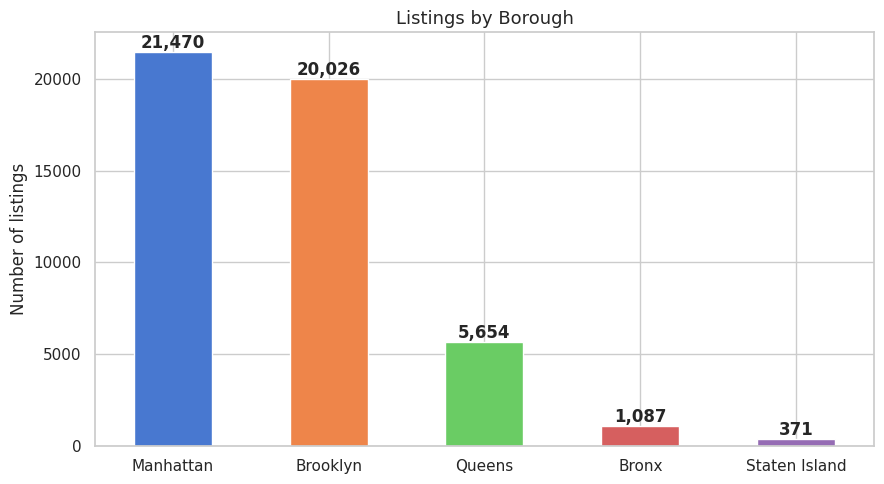

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
borough_counts.plot(kind="bar", ax=ax, color=sns.color_palette("muted"))
ax.set_title("Listings by Borough", fontsize=13)
ax.set_ylabel("Number of listings")
ax.set_xlabel("")
plt.xticks(rotation=0)
for i, v in enumerate(borough_counts.values):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Price by borough

Manhattan averages **$179/night, 2.1× the Bronx** ($85). Brooklyn sits in the middle at $118. The box plot on the right shows that the distributions are wide and right-skewed everywhere — there are luxury listings in every borough, but the typical (median) price gap is real and consistent.

In [9]:
summary = (df.groupby("neighbourhood_group")
              .agg(listings=("id", "count"),
                   mean_price=("price", "mean"),
                   median_price=("price", "median"),
                   avg_availability=("availability_365", "mean"))
              .round(1)
              .sort_values("mean_price", ascending=False))
summary

,listings,mean_price,median_price,avg_availability
neighbourhood_group,,,,
Manhattan,21470,179.00,149.00,111.50
Brooklyn,20026,117.90,90.00,100.00
Staten Island,371,98.60,75.00,199.80
Queens,5654,95.00,75.00,144.30
Bronx,1087,85.30,65.00,165.70


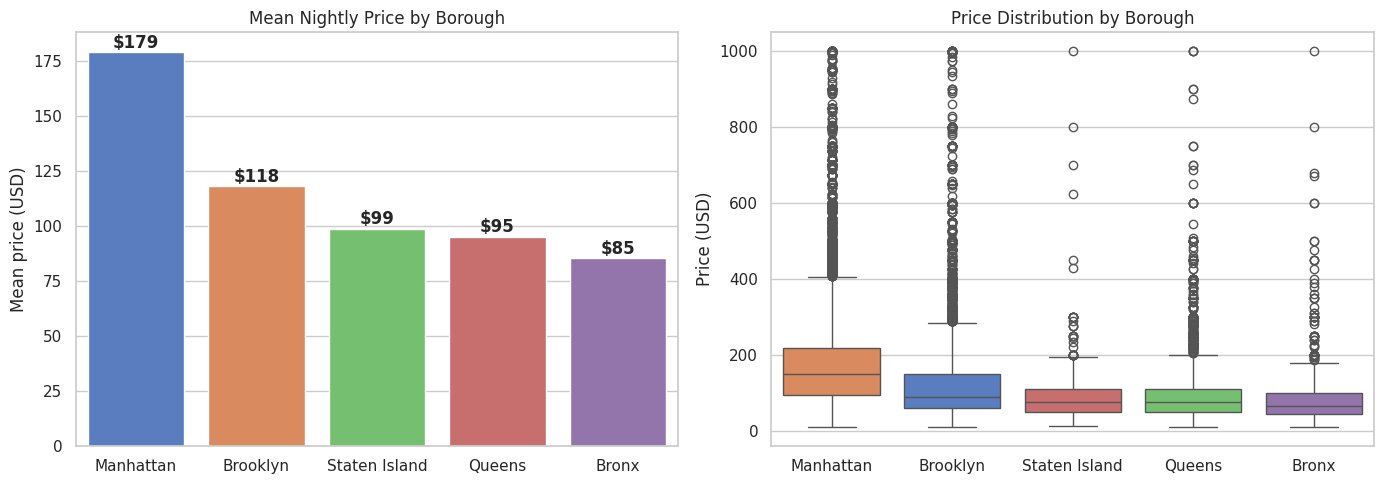

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = summary.index.tolist()

mean_price = df.groupby("neighbourhood_group")["price"].mean().reindex(order)
sns.barplot(x=mean_price.index, y=mean_price.values,
            hue=mean_price.index, legend=False, ax=axes[0])
axes[0].set_title("Mean Nightly Price by Borough")
axes[0].set_ylabel("Mean price (USD)"); axes[0].set_xlabel("")
for i, v in enumerate(mean_price.values):
    axes[0].text(i, v + 2, f"${v:.0f}", ha="center", fontweight="bold")

sns.boxplot(data=df, x="neighbourhood_group", y="price",
            order=order, hue="neighbourhood_group", legend=False, ax=axes[1])
axes[1].set_title("Price Distribution by Borough")
axes[1].set_ylabel("Price (USD)"); axes[1].set_xlabel("")

plt.tight_layout(); plt.show()

## 7. Room type drives a large price premium

Entire homes/apartments command a sharp premium over private rooms, and shared rooms are the cheapest by far across every borough. This pattern is consistent — the borough effect and the room-type effect stack.

In [11]:
room_borough = (df.groupby(["neighbourhood_group", "room_type"])["price"]
                  .mean().unstack().round(0))
room_borough

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,128.00,63.00,59.00
Brooklyn,169.00,73.00,51.00
Manhattan,225.00,109.00,89.00
Queens,142.00,68.00,54.00
Staten Island,140.00,62.00,57.00


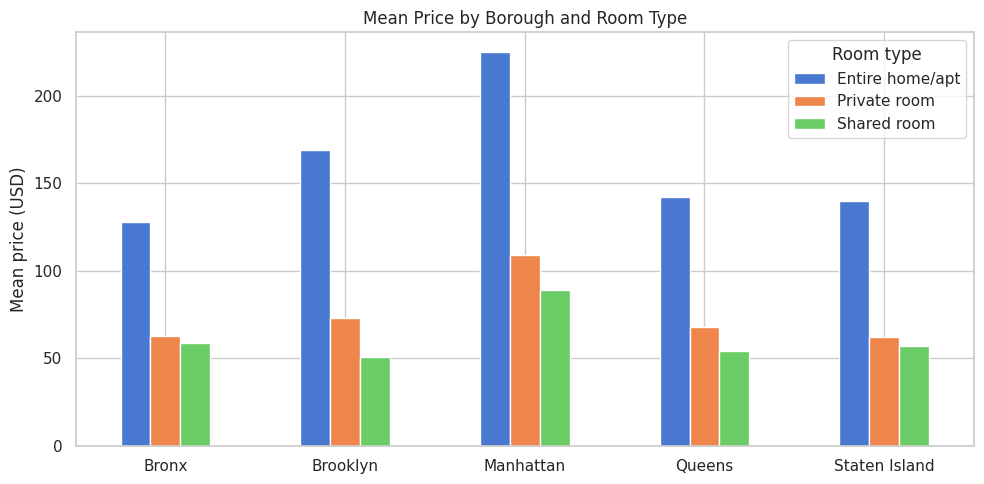

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
room_borough.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Mean Price by Borough and Room Type")
ax.set_ylabel("Mean price (USD)"); ax.set_xlabel("")
ax.legend(title="Room type")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 8. Host concentration: how commercial is this market?

A natural question is whether NYC Airbnb is mostly casual hosts renting out a spare room, or commercial operators running it as a hotel business. The data shows clear evidence of the latter.

- **13.8% of hosts manage multiple listings**
- **Top 1% of hosts control ~10% of all listings**
- **The single largest host operates 327 listings** — clearly a commercial operation, not a casual host

In [13]:
host_counts = df["host_id"].value_counts()
total = len(df)
top_1pct_n = max(1, len(host_counts) // 100)

print(f"Total unique hosts:              {len(host_counts):,}")
print(f"Hosts with >1 listing:           {(host_counts > 1).sum():,} ({(host_counts > 1).mean():.1%})")
print(f"Top 1% of hosts ({top_1pct_n} hosts) control:  {host_counts.head(top_1pct_n).sum() / total:.1%} of listings")
print(f"Largest single host has:         {host_counts.iloc[0]} listings")

Total unique hosts:              37,251
Hosts with >1 listing:           5,129 (13.8%)
Top 1% of hosts (372 hosts) control:  10.1% of listings
Largest single host has:         327 listings


In [14]:
top10_hosts = (df.groupby(["host_id", "host_name"])
                 .size().reset_index(name="listings")
                 .sort_values("listings", ascending=False).head(10))
top10_hosts

,host_id,host_name,listings
34461,219517861,Sonder (NYC),327
29250,107434423,Blueground,232
19469,30283594,Kara,119
30914,137358866,Kazuya,103
14355,16098958,Jeremy & Laura,96
12728,12243051,Sonder,96
25526,61391963,Corporate Housing,91
17000,22541573,Ken,87
33687,200380610,Pranjal,65
9684,7503643,Vida,52


## 9. What numeric features correlate with price?

Honest answer from the correlation matrix: not much, linearly. The strongest numeric correlations with price are all weak (|r| < 0.1). This tells us:

- Price is driven primarily by **categorical features** (room type, borough) and **location** (lat/lon)
- A linear model will struggle; a tree-based model that can carve up lat/lon space will do better
- This motivates the XGBoost approach in `03_ml_pipeline.py`

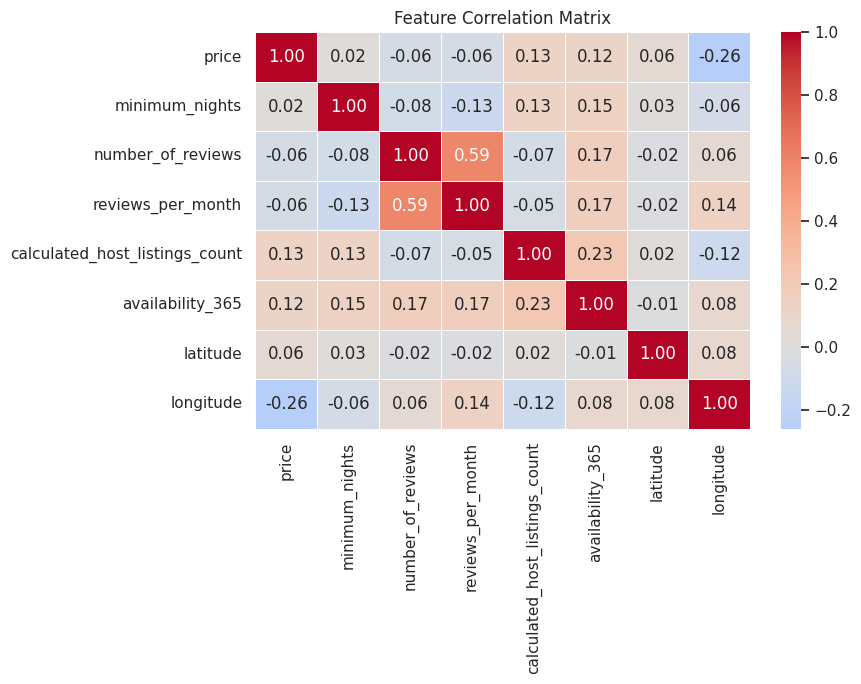

In [15]:
numeric = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month",
           "calculated_host_listings_count", "availability_365", "latitude", "longitude"]
corr = df[numeric].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Feature Correlation Matrix"); plt.tight_layout(); plt.show()

## 10. Price distribution: log-transform helps

The raw price distribution is heavily right-skewed. A log transformation makes the distribution close to normal — useful both for visualization and as a target transformation for the ML model.

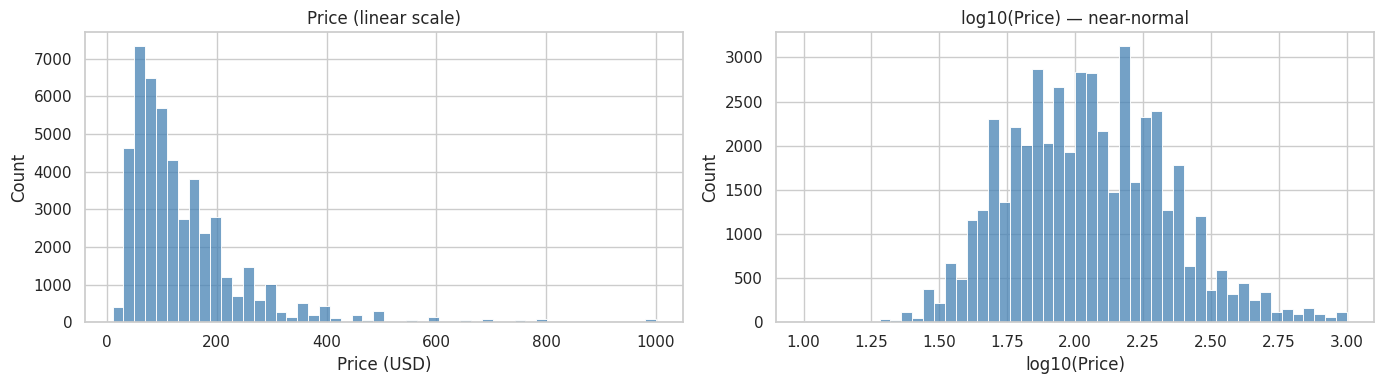

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["price"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Price (linear scale)"); axes[0].set_xlabel("Price (USD)")

sns.histplot(np.log10(df["price"]), bins=50, ax=axes[1], color="steelblue")
axes[1].set_title("log10(Price) — near-normal")
axes[1].set_xlabel("log10(Price)")
plt.tight_layout(); plt.show()

## 11. Spatial pattern

The original 2019 coursework never used the latitude/longitude columns. Plotting them reveals the obvious-in-hindsight pattern: a dense, high-priced cluster in lower-to-midtown Manhattan, a long high-priced ridge along the Brooklyn waterfront, and progressively cheaper listings as you move outward. This is why latitude and longitude are the strongest features in the ML model — they encode neighborhood quality far better than the coarse borough labels.

In [17]:
sample = df.sample(min(8000, len(df)), random_state=42)
fig = px.scatter_mapbox(
    sample, lat="latitude", lon="longitude",
    color=np.log10(sample["price"]),
    zoom=10, center={"lat": 40.73, "lon": -73.95},
    mapbox_style="open-street-map", color_continuous_scale="Viridis",
    hover_data={"price": True, "room_type": True, "neighbourhood": True},
    title="NYC Airbnb Listings — log10(price)", height=600,
)
fig.update_layout(coloraxis_colorbar=dict(title="log10(price)"))
fig.show()

/tmp/ipykernel_565/1465812989.py:2: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


## 12. Save the cleaned dataset

The next scripts (`02_sql_analysis.sql`, `03_ml_pipeline.py`, `04_dashboard.py`) all expect the cleaned version saved here.

In [18]:
df.to_csv("airbnb_clean.csv", index=False)
print(f"Saved airbnb_clean.csv with {len(df):,} rows, {df.shape[1]} columns")

Saved airbnb_clean.csv with 48,608 rows, 16 columns


## Key takeaways

| Question | Finding |
|----------|---------|
| Where are listings concentrated? | Manhattan + Brooklyn = ~85% of the market |
| How much do boroughs differ in price? | Manhattan averages **2.1× the Bronx** ($179 vs $85) |
| Does room type matter? | Yes — entire homes are roughly **2× the price of private rooms** in every borough |
| Is this a casual or commercial market? | The top 1% of hosts control **~10%** of listings; the largest operates **327 properties** — meaningful commercial presence |
| What drives price? | Primarily **location** (lat/lon) and **room type** — see `03_ml_pipeline.py` for the full model |

**Next steps in this project:**
- `02_sql_analysis.sql` — analytical SQL queries (CTEs, window functions) on a SQLite version of the data
- `03_ml_pipeline.py` — XGBoost price prediction with hyperparameter tuning
- `04_dashboard.py` — interactive Streamlit dashboard for filtering and live price prediction